# **Chapter4: Transformers**

This chapter introduces Transformers in a gradual and intuitive way. We explain the key concepts, illustrate them with simple diagrams, and then treat examples in both **Natural Language Processing** and **Computer Vision**.


## **Setup and data preparation**

To keep the notebook self-contained, this chapter uses small local text examples for the language section and the built-in `digits` dataset for the vision section. This keeps the practical examples consistent, lightweight, and easy to run locally.


In [1]:
# Required modules

import math
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
torch.manual_seed(42)
np.random.seed(42)


## **What is a Transformer?**


A **Transformer** is a neural-network architecture designed to process sequences by learning how each element should pay attention to the others. Instead of relying on recurrence, a transformer uses **self-attention** to determine which parts of the input are most relevant when constructing a representation. This makes the architecture flexible, scalable, and highly effective across many domains.


## **Why transformers matter**


Transformers became important because they can model **long-range dependencies** very effectively and can also be trained in parallel more easily than recurrent models. They are now central to **Natural Language Processing**, and the same attention-based ideas have also become very influential in **Computer Vision**, multimodal systems, and generative AI.


## **Core building blocks of a transformer**


**1. Token embeddings**

Raw inputs are first converted into vectors so that the model can process them numerically.

**2. Positional encoding**

Since attention alone does not know the order of the sequence, positional information is added to each token representation.

**3. Self-attention**

Each token compares itself with other tokens and learns which ones are important.

**4. Multi-head attention**

Multiple attention heads allow the model to learn different kinds of relationships at the same time.

**5. Feed-forward network**

After attention, each token passes through a small neural network for further transformation.

**6. Residual connections and layer normalization**

These components help stabilize training and improve gradient flow.


## **Diagram: high-level transformer flow**


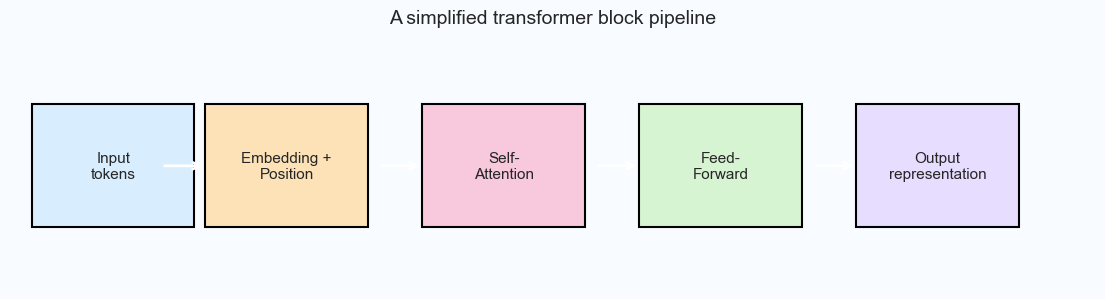

In [2]:
fig, ax = plt.subplots(figsize=(14, 3.2), facecolor='#f8fbff')
ax.axis('off')

blocks = [
    ('Input\ntokens', 0.02, '#d8eefe'),
    ('Embedding +\nPosition', 0.18, '#fde2b8'),
    ('Self-\nAttention', 0.38, '#f8c8dc'),
    ('Feed-\nForward', 0.58, '#d7f4d2'),
    ('Output\nrepresentation', 0.78, '#e6ddff'),
]

for label, x, color in blocks:
    rect = plt.Rectangle((x, 0.25), 0.15, 0.5, facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + 0.075, 0.5, label, ha='center', va='center', fontsize=11)

for x in [0.14, 0.34, 0.54, 0.74]:
    ax.annotate('', xy=(x + 0.04, 0.5), xytext=(x, 0.5), arrowprops=dict(arrowstyle='->', lw=2))

ax.set_title('A simplified transformer block pipeline', fontsize=14, pad=14)
plt.show()


## **How self-attention works**


For each token, the transformer creates three vectors:

- **Query (Q)**: what this token is looking for
- **Key (K)**: what this token offers
- **Value (V)**: the information carried by this token

Attention scores are obtained by comparing queries with keys, and those scores are then used to combine the value vectors into a new representation.


## **Diagram: a small attention example**


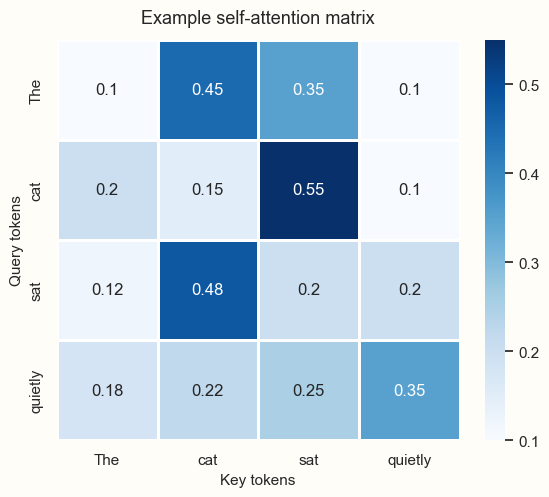

In [3]:
tokens = ['The', 'cat', 'sat', 'quietly']
attention = np.array([
    [0.10, 0.45, 0.35, 0.10],
    [0.20, 0.15, 0.55, 0.10],
    [0.12, 0.48, 0.20, 0.20],
    [0.18, 0.22, 0.25, 0.35],
])

plt.figure(figsize=(6.5, 5.2), facecolor='#fffdf8')
sns.heatmap(attention, annot=True, cmap='Blues', linewidths=1, linecolor='white', xticklabels=tokens, yticklabels=tokens)
plt.title('Example self-attention matrix', pad=12)
plt.xlabel('Key tokens')
plt.ylabel('Query tokens')
plt.show()


Each row shows how strongly one token attends to the others. For example, if the row for `sat` gives a high score to `cat`, the model is using that relationship while building the representation of `sat`.


## **Positional encoding**


Transformers need a way to represent order. One common approach is to add **positional encodings** to token embeddings. This allows the model to distinguish between sequences that contain the same words but in a different arrangement.


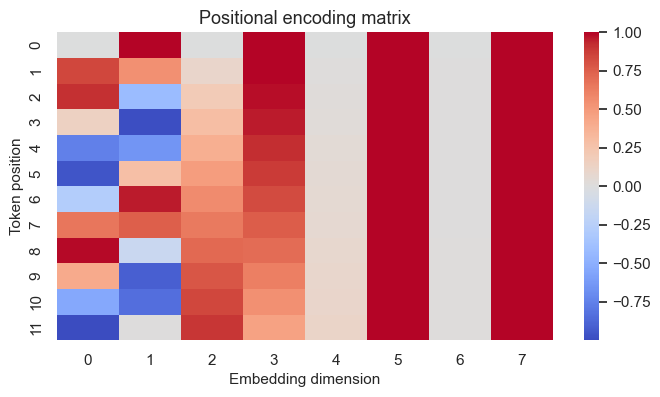

In [4]:
def positional_encoding(length, d_model):
    pe = torch.zeros(length, d_model)
    position = torch.arange(0, length, dtype=torch.float32).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

pe = positional_encoding(12, 8).numpy()
plt.figure(figsize=(8, 4))
sns.heatmap(pe, cmap='coolwarm')
plt.title('Positional encoding matrix')
plt.xlabel('Embedding dimension')
plt.ylabel('Token position')
plt.show()


## **A minimal PyTorch attention example**

Before moving to full applications, the next cell shows a very small example of multi-head attention in PyTorch.


In [5]:
embedding = nn.Embedding(num_embeddings=10, embedding_dim=8)
sequence = torch.tensor([[1, 4, 2, 7]])
x = embedding(sequence)

attention_layer = nn.MultiheadAttention(embed_dim=8, num_heads=2, batch_first=True)
attended, attn_weights = attention_layer(x, x, x)

print('Input shape:', x.shape)
print('Attention output shape:', attended.shape)
print('Attention weights shape:', attn_weights.shape)


Input shape: torch.Size([1, 4, 8])
Attention output shape: torch.Size([1, 4, 8])
Attention weights shape: torch.Size([1, 4, 4])


## **Transformers in Natural Language Processing**


Transformers became especially popular in NLP because language is sequential and often depends on long-range relationships. They are widely used for tasks such as:

- text classification
- machine translation
- summarization
- question answering
- next-token prediction and text generation


## **NLP example: sentence sentiment classification**


In this example, each sentence is converted into token IDs, passed through an embedding layer and a transformer encoder, and then classified as **positive** or **negative**.


In [6]:
sentences = [
    'this movie is wonderful',
    'the film was boring',
    'i loved the acting',
    'the plot was terrible',
    'what a fantastic story',
    'i dislike this movie',
    'the ending was amazing',
    'the dialogue was dull',
    'an excellent performance',
    'this was a bad film',
]
labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]

tokenized = [sentence.split() for sentence in sentences]
vocab = {'<pad>': 0, '<unk>': 1}
for sentence in tokenized:
    for token in sentence:
        if token not in vocab:
            vocab[token] = len(vocab)

max_len = max(len(sentence) for sentence in tokenized)

def encode(sentence):
    ids = [vocab.get(token, vocab['<unk>']) for token in sentence]
    ids += [vocab['<pad>']] * (max_len - len(ids))
    return ids

X = torch.tensor([encode(sentence) for sentence in tokenized], dtype=torch.long)
y = torch.tensor(labels, dtype=torch.long)
print('Vocabulary size:', len(vocab))
print('Encoded input shape:', X.shape)


Vocabulary size: 28
Encoded input shape: torch.Size([10, 5])


In [7]:
class SentimentTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, num_heads=4, hidden_dim=64, num_classes=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            batch_first=True,
            dropout=0.0,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = self.encoder(x)
        x = x.mean(dim=1)
        return self.classifier(x)

nlp_model = SentimentTransformer(vocab_size=len(vocab))
print(nlp_model)


SentimentTransformer(
  (embedding): Embedding(28, 32)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0): TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (classifier): Linear(in_features=32, out_features=2, bias=True)
)


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(nlp_model.parameters(), lr=0.01)

for epoch in range(40):
    optimizer.zero_grad()
    logits = nlp_model(X)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    predictions = nlp_model(X).argmax(dim=1)
    accuracy = (predictions == y).float().mean().item()

print(f'NLP example training accuracy: {accuracy * 100:.2f}%')
for sentence, pred in zip(sentences, predictions.tolist()):
    label = 'positive' if pred == 1 else 'negative'
    print(f'{sentence!r} -> {label}')


NLP example training accuracy: 100.00%
'this movie is wonderful' -> positive
'the film was boring' -> negative
'i loved the acting' -> positive
'the plot was terrible' -> negative
'what a fantastic story' -> positive
'i dislike this movie' -> negative
'the ending was amazing' -> positive
'the dialogue was dull' -> negative
'an excellent performance' -> positive
'this was a bad film' -> negative


## **Why transformers work well for NLP**

A transformer can relate one word to another even when the two words are far apart in the sentence. Different attention heads can learn different linguistic patterns, and the same core architecture can be adapted to many language tasks with only small changes to the output layer.


- Words can attend to other words even when they are far apart.
- The model can learn different linguistic patterns through multiple heads.
- The same architecture can support many tasks with only small changes to the output layer.


## **Transformers in Computer Vision**


Transformers are also used in computer vision. Instead of treating the whole image as one large grid directly, a Vision Transformer often divides the image into **patches** and treats each patch like a token.


## **Diagram: image patches as tokens**


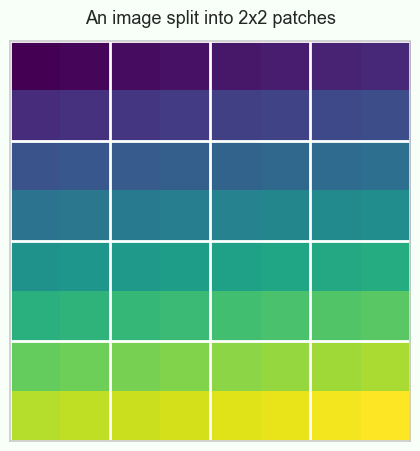

In [9]:
image = np.arange(64).reshape(8, 8)
fig, ax = plt.subplots(figsize=(5.2, 5.2), facecolor='#f7fff8')
ax.imshow(image, cmap='viridis')
for i in range(0, 9, 2):
    ax.axhline(i - 0.5, color='white', linewidth=2)
    ax.axvline(i - 0.5, color='white', linewidth=2)
ax.set_title('An image split into 2x2 patches', pad=12)
ax.set_xticks([])
ax.set_yticks([])
plt.show()


Each patch is flattened and projected into an embedding vector. Those patch embeddings are then processed by a transformer in much the same way that word embeddings are processed in NLP.


## **Computer vision example: classifying digits with a patch-based transformer idea**

We will again use the built-in `digits` dataset so the transition from chapter 3 remains smooth. Each `8x8` image is split into small `2x2` patches, and each patch is treated like a token before passing through a transformer encoder.


We will use the built-in `digits` dataset. Each `8x8` image is split into `2x2` patches. Each patch becomes a token, and the full sequence of patches is passed through a transformer encoder before classification.


In [10]:
digits = load_digits()
X = digits.images / 16.0
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64, shuffle=False)

print(X_train_tensor.shape)
print(X_test_tensor.shape)


torch.Size([1437, 8, 8])
torch.Size([360, 8, 8])


In [11]:
def image_to_patches(images, patch_size=2):
    batch_size, height, width = images.shape
    patches = images.unfold(1, patch_size, patch_size).unfold(2, patch_size, patch_size)
    patches = patches.contiguous().view(batch_size, -1, patch_size * patch_size)
    return patches

sample_patches = image_to_patches(X_train_tensor[:2])
print('Patch tensor shape:', sample_patches.shape)


Patch tensor shape: torch.Size([2, 16, 4])


In [12]:
class VisionTransformerSmall(nn.Module):
    def __init__(self, patch_dim=4, num_patches=16, embed_dim=32, num_heads=4, hidden_dim=64, num_classes=10):
        super().__init__()
        self.patch_embed = nn.Linear(patch_dim, embed_dim)
        self.position_embed = nn.Parameter(torch.zeros(1, num_patches, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            batch_first=True,
            dropout=0.0,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.classifier = nn.Linear(embed_dim, num_classes)

    def forward(self, images):
        patches = image_to_patches(images)
        x = self.patch_embed(patches)
        x = x + self.position_embed
        x = self.encoder(x)
        x = x.mean(dim=1)
        return self.classifier(x)

vit_model = VisionTransformerSmall()
print(vit_model)


VisionTransformerSmall(
  (patch_embed): Linear(in_features=4, out_features=32, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (classifier): Linear(in_features=32, out_features=10, bias=True)
)


In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vit_model.parameters(), lr=0.001)

history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
best_state = copy.deepcopy(vit_model.state_dict())
best_val_loss = float('inf')

for epoch in range(15):
    vit_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images_batch, labels_batch in train_loader:
        optimizer.zero_grad()
        outputs = vit_model(images_batch)
        loss = criterion(outputs, labels_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * labels_batch.size(0)
        train_correct += (outputs.argmax(dim=1) == labels_batch).sum().item()
        train_total += labels_batch.size(0)

    vit_model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images_batch, labels_batch in test_loader:
            outputs = vit_model(images_batch)
            loss = criterion(outputs, labels_batch)
            val_loss += loss.item() * labels_batch.size(0)
            val_correct += (outputs.argmax(dim=1) == labels_batch).sum().item()
            val_total += labels_batch.size(0)

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total
    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    history['loss'].append(epoch_train_loss)
    history['accuracy'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_acc)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_state = copy.deepcopy(vit_model.state_dict())

    print(
        f"Epoch {epoch + 1:02d} | "
        f"train_loss={epoch_train_loss:.4f} | train_acc={epoch_train_acc:.4f} | "
        f"val_loss={epoch_val_loss:.4f} | val_acc={epoch_val_acc:.4f}"
    )

vit_model.load_state_dict(best_state)


Epoch 01 | train_loss=2.3308 | train_acc=0.0981 | val_loss=2.3151 | val_acc=0.0972
Epoch 02 | train_loss=2.3078 | train_acc=0.1051 | val_loss=2.2881 | val_acc=0.1111
Epoch 03 | train_loss=2.2832 | train_acc=0.1287 | val_loss=2.2549 | val_acc=0.2167
Epoch 04 | train_loss=2.2245 | train_acc=0.2067 | val_loss=2.1442 | val_acc=0.3389
Epoch 05 | train_loss=1.9600 | train_acc=0.4127 | val_loss=1.6565 | val_acc=0.5389
Epoch 06 | train_loss=1.4914 | train_acc=0.5150 | val_loss=1.3064 | val_acc=0.6028
Epoch 07 | train_loss=1.1964 | train_acc=0.6451 | val_loss=1.0793 | val_acc=0.6583
Epoch 08 | train_loss=0.9612 | train_acc=0.7126 | val_loss=0.8768 | val_acc=0.7167
Epoch 09 | train_loss=0.7540 | train_acc=0.7745 | val_loss=0.7265 | val_acc=0.7917
Epoch 10 | train_loss=0.6501 | train_acc=0.8017 | val_loss=0.6839 | val_acc=0.7806
Epoch 11 | train_loss=0.5489 | train_acc=0.8344 | val_loss=0.5638 | val_acc=0.8389
Epoch 12 | train_loss=0.4652 | train_acc=0.8566 | val_loss=0.5267 | val_acc=0.8444
Epoc

<All keys matched successfully>

## **Training and validation accuracy plot**

The following plot shows how the patch-based transformer improves during training.


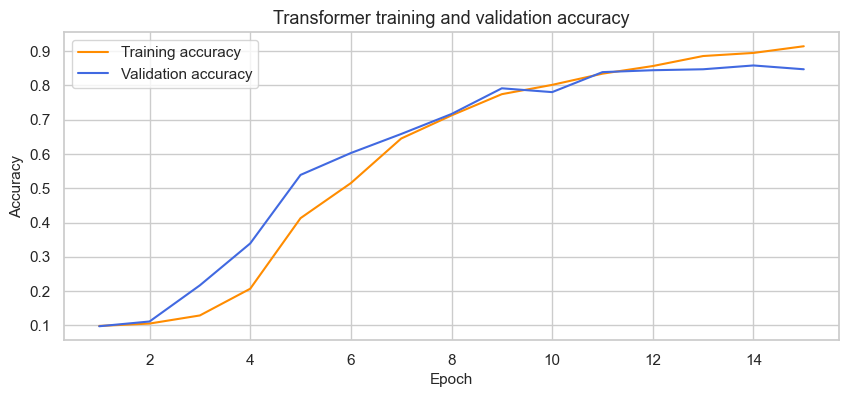

In [14]:
epochs = range(1, len(history['accuracy']) + 1)
plt.figure(figsize=(10, 4))
plt.plot(epochs, history['accuracy'], label='Training accuracy', color='darkorange')
plt.plot(epochs, history['val_accuracy'], label='Validation accuracy', color='royalblue')
plt.title('Transformer training and validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## **Evaluate the vision transformer example**

After training, we evaluate the model on unseen digit images to measure its classification performance.


In [15]:
vit_model.eval()
with torch.no_grad():
    y_pred = vit_model(X_test_tensor).argmax(dim=1).numpy()

accuracy = accuracy_score(y_test, y_pred)
print(f'Vision transformer example accuracy: {accuracy * 100:.2f}%')
print(classification_report(y_test, y_pred))


Vision transformer example accuracy: 84.72%
              precision    recall  f1-score   support

           0       0.97      0.94      0.96        36
           1       0.81      0.69      0.75        36
           2       0.80      0.91      0.85        35
           3       0.85      0.78      0.82        37
           4       0.97      0.78      0.86        36
           5       0.90      0.95      0.92        37
           6       0.69      0.94      0.80        36
           7       0.84      1.00      0.91        36
           8       0.91      0.86      0.88        35
           9       0.81      0.61      0.70        36

    accuracy                           0.85       360
   macro avg       0.85      0.85      0.84       360
weighted avg       0.85      0.85      0.84       360



## **Confusion matrix**


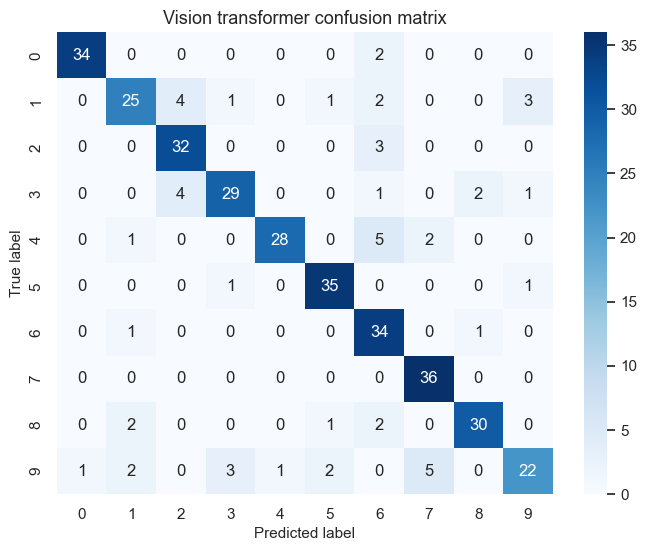

In [16]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Vision transformer confusion matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()


## **Compare transformer use in NLP and vision**



- In **NLP**, tokens are usually words, subwords, or characters.
- In **vision**, tokens are usually image patches.
- In both cases, the transformer learns relationships between tokens through attention.
- This is why the same core architecture can be adapted to very different data types.


## **Summary**



In this chapter, you learned that:

- Transformers rely on **self-attention** rather than recurrence.
- Positional information is required because token order still matters.
- Transformers are central to many **Natural Language Processing** tasks.
- Patch-based transformer ideas can also be used in **Computer Vision**.
- PyTorch provides convenient components such as `nn.MultiheadAttention` and `nn.TransformerEncoderLayer` for building transformer models.
